# **RESEARCH QUESTION**

1. Bagaimana korelasi antara metrik gaya hidup harian dengan kualitas tidur dan gangguan tidur?
2. Bagaimana model Deep Learning dapat mengklasifikasikan kualitas tidur seseorang secara akurat berdasarkan data tabular metrik gaya hidup?

# **GATHERING DAN ASSESING DATA**

In [ ]:
import pandas as pd

# Load dataset dari Google Drive
file_id = '1hEhusQq2sIv6PZQwDi2Q7NFWprBCdXz_'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)
print(df.shape)

(374, 13)


In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
import pandas as pd
!pip install sdv -q

from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

# Pakai data asli sebagai dasar
df_asli = df # Use the DataFrame already loaded from Google Drive

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_asli)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_asli)

df = synthesizer.sample(num_rows=3000)

## Dataset asli berjumlah 374 baris. Untuk keperluan capstone project, dataset diperbanyak menggunakan synthetic data menjadi 3000 baris.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.5/204.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1399833,Female,55,Accountant,7.24,7,54,3,Overweight,140/95,68,8425,Sleep Apnea
1,8754128,Female,42,Accountant,8.11,8,69,4,Normal,135/90,66,7845,NaN
2,14342759,Female,56,Lawyer,8.44,9,87,5,Overweight,140/95,68,9588,NaN
3,9916151,Female,38,Engineer,6.12,7,37,3,Normal,125/80,71,4657,NaN
4,10833063,Male,38,Engineer,6.58,6,40,7,Normal,130/85,72,6010,NaN


In [ ]:
# Cek tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                3000 non-null   int64  
 1   Gender                   3000 non-null   object 
 2   Age                      3000 non-null   int64  
 3   Occupation               3000 non-null   object 
 4   Sleep Duration           3000 non-null   float64
 5   Quality of Sleep         3000 non-null   int64  
 6   Physical Activity Level  3000 non-null   int64  
 7   Stress Level             3000 non-null   int64  
 8   BMI Category             3000 non-null   object 
 9   Blood Pressure           3000 non-null   object 
 10  Heart Rate               3000 non-null   int64  
 11  Daily Steps              3000 non-null   int64  
 12  Sleep Disorder           1219 non-null   object 
dtypes: float64(1), int64(7), object(5)
memory usage: 304.8+ KB


In [ ]:
# Cek missing values
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
# Cek data duplikat
print("Duplikat:", df.duplicated().sum())

Duplikat: 0


In [ ]:
# Cek statistik dasar
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,8.414288e+06,43.140000,7.089903,7.312333,61.897000,5.381667,70.405667,6816.668000
std,4.807659e+06,9.388634,0.801746,1.219266,17.815841,1.765324,3.777635,1593.237943
min,1.846000e+03,27.000000,5.900000,4.000000,32.000000,3.000000,65.000000,3000.000000
25%,4.299330e+06,35.000000,6.370000,6.000000,46.000000,4.000000,67.000000,5641.000000
50%,8.345657e+06,43.000000,7.020000,7.000000,63.000000,5.000000,70.000000,6790.000000
75%,1.253389e+07,51.000000,7.800000,8.000000,78.000000,7.000000,73.000000,7983.250000
max,1.676158e+07,59.000000,8.550000,9.000000,90.000000,8.000000,83.000000,10000.000000


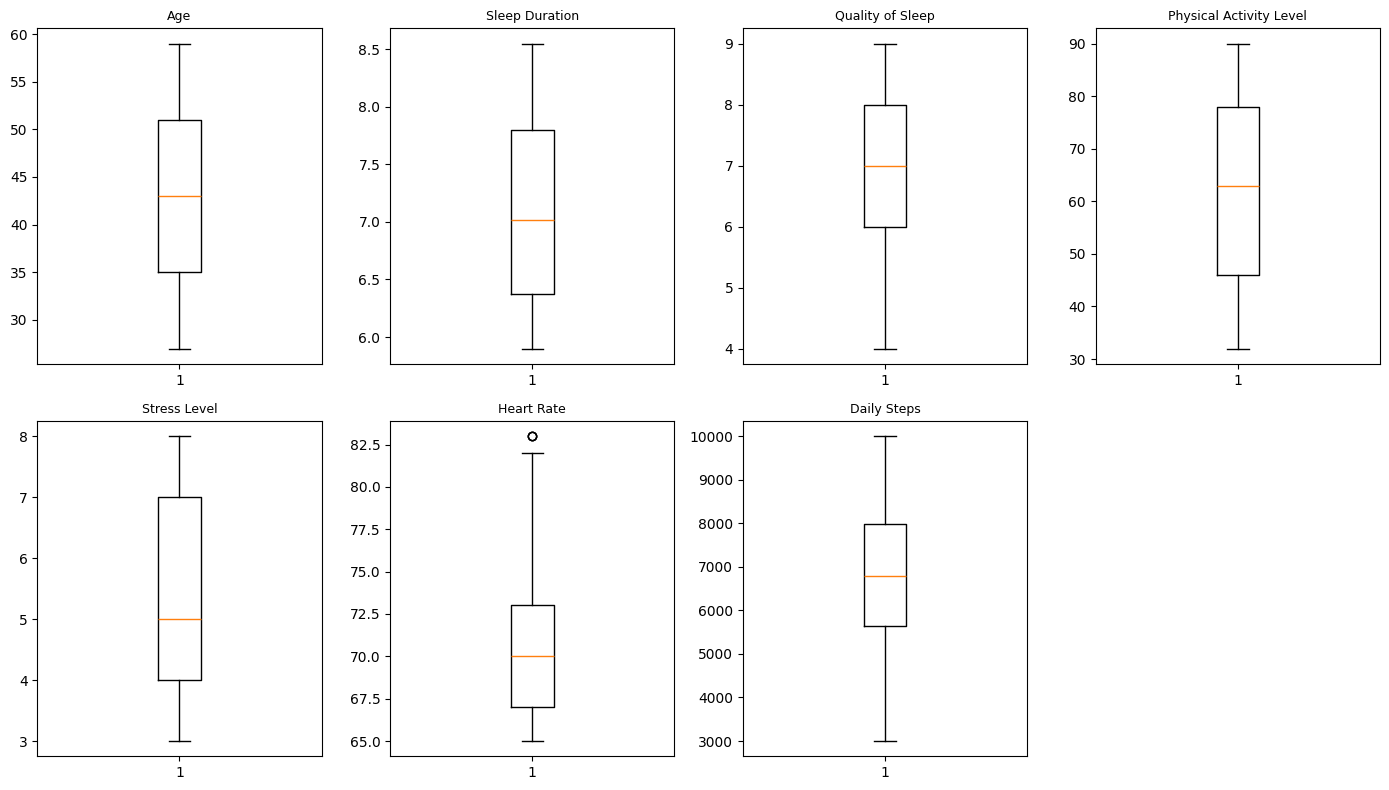

In [ ]:
import matplotlib.pyplot as plt

num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep',
            'Physical Activity Level', 'Stress Level',
            'Heart Rate', 'Daily Steps']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    plt.boxplot(df[col])
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.show()

# **HASIL ASESSING**

1. Dataset terdiri dari 3000 baris dan 13 kolom yang telah di sintetis dari data aslinya
2. Semua tipe datanya benar
3. Ditemukan missing values sebanyak 1759 pada kolom sleep disorder
4. Tidak ditemukan data duplikat
5. Ditemukan outlier pada kolom heart rate, namun masih dalam batas wajar detak jantung manusia

# **CLEANING DATA**

In [ ]:
# Isi missing values Sleep Disorder
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
print("Sleep Disorder setelah diisi:")
print(df['Sleep Disorder'].value_counts())

print("\nMissing values setelah cleaning:")
print(df.isnull().sum())

Sleep Disorder setelah diisi:
Sleep Disorder
None           1781
Insomnia        642
Sleep Apnea     577
Name: count, dtype: int64

Missing values setelah cleaning:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


# **EXPLORATORY DATA ANALYSIS (EDA)**

/tmp/ipykernel_2741/857939211.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sleep Disorder', palette='Set2', ax=axes[0,0])
/tmp/ipykernel_2741/857939211.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Occupation', y='Sleep Duration', palette='Set3', ax=axes[1,1])


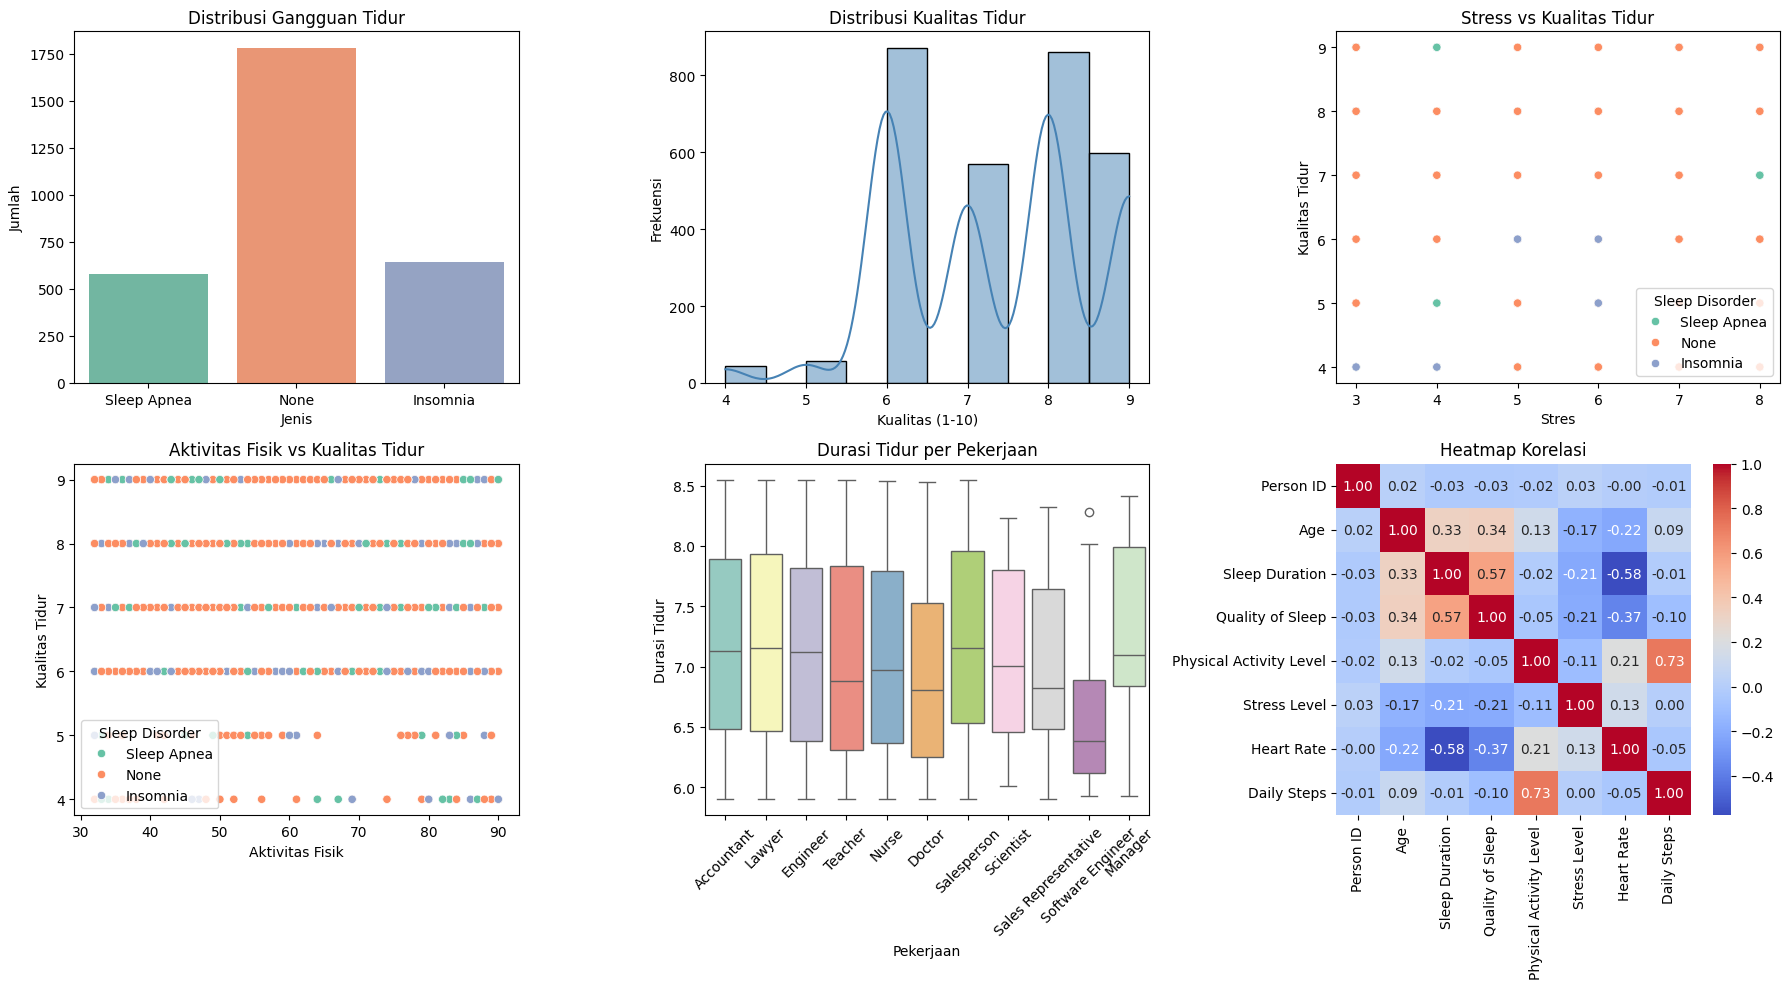

In [ ]:
 import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribusi Sleep Disorder
sns.countplot(data=df, x='Sleep Disorder', palette='Set2', ax=axes[0,0])
axes[0,0].set(title='Distribusi Gangguan Tidur', xlabel='Jenis', ylabel='Jumlah')

# 2. Distribusi Quality of Sleep
sns.histplot(data=df, x='Quality of Sleep', bins=10, kde=True, color='steelblue', ax=axes[0,1])
axes[0,1].set(title='Distribusi Kualitas Tidur', xlabel='Kualitas (1-10)', ylabel='Frekuensi')

# 3. Stress Level vs Quality of Sleep
sns.scatterplot(data=df, x='Stress Level', y='Quality of Sleep', hue='Sleep Disorder', palette='Set2', ax=axes[0,2])
axes[0,2].set(title='Stress vs Kualitas Tidur', xlabel='Stres', ylabel='Kualitas Tidur')

# 4. Physical Activity vs Quality of Sleep
sns.scatterplot(data=df, x='Physical Activity Level', y='Quality of Sleep', hue='Sleep Disorder', palette='Set2', ax=axes[1,0])
axes[1,0].set(title='Aktivitas Fisik vs Kualitas Tidur', xlabel='Aktivitas Fisik', ylabel='Kualitas Tidur')

# 5. Sleep Duration per Occupation
sns.boxplot(data=df, x='Occupation', y='Sleep Duration', palette='Set3', ax=axes[1,1])
axes[1,1].set(title='Durasi Tidur per Pekerjaan', xlabel='Pekerjaan', ylabel='Durasi Tidur')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Heatmap Korelasi
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set(title='Heatmap Korelasi')

plt.tight_layout()
plt.show()

# **HASIL EXPLORATORY DATA ANALYSIS (EDA)**

Distribusi Data Numerik:
- Sleep Duration: Durasi tidur responden tersebar antara 5.8 hingga 8.5 jam. Distribusi data cukup stabil tanpa outlier ekstrem yang mengganggu.
- Quality of Sleep: Sebagian besar responden memiliki kualitas tidur dengan skor antara 6 hingga 8. Skor terendah adalah 4 dan tertinggi adalah 9.
- Stress Level: Tingkat stres bervariasi antara 3 hingga 8.
- Heart Rate & Daily Steps: Variabel Heart Rate menunjukkan adanya outlier (data pencilan), namun masih dalam batas wajar detak jantung manusia. Daily Steps memiliki variasi yang cukup luas (3000 - 10000 langkah).


Korelasi Fitur:
- Terdapat indikasi korelasi negatif antara Stress Level dan Quality of Sleep. Hal ini menunjukkan bahwa semakin tinggi tingkat stres seseorang, semakin rendah kualitas tidurnya.
- Terdapat indikasi korelasi positif antara Physical Activity Level dan Quality of Sleep. Aktivitas fisik yang lebih baik cenderung berkorelasi dengan kualitas tidur yang lebih baik.

Distribusi Target (Sleep Disorder):
- Data target menunjukkan ketidakseimbangan kelas (Class Imbalance). Sebagian besar data memiliki label 'None' (tidak ada gangguan tidur), diikuti oleh 'Sleep Apnea' dan 'Insomnia'. Hal ini perlu diperhatikan pada tahap modeling agar model tidak bias terhadap kelas mayoritas.

Kesimpulan Preprocessing:
- Karena dataset ini merupakan data sintetis yang digabungkan dengan data asli, struktur datanya sudah rapi.
- Variabel kategorikal seperti Gender, Occupation, dan BMI Category perlu diubah menjadi numerik menggunakan Label Encoding atau One-Hot Encoding.
- Variabel numerik perlu dilakukan Scaling (Standarisasi) agar memiliki skala yang seragam sebelum dimasukkan ke dalam model Deep Learning.

In [ ]:
# %% [markdown]
# # **🔹 PREPROCESSING & SPLIT DATA**
# %% [code]
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Salin dataframe agar data asli tidak termodifikasi
df_ml = df.copy()

# 1. Pisahkan Blood Pressure menjadi Systolic & Diastolic (numerik lebih informatif)
df_ml[['Systolic', 'Diastolic']] = df_ml['Blood Pressure'].str.split('/', expand=True).astype(float)
df_ml = df_ml.drop(columns=['Person ID', 'Blood Pressure'])

# 2. Encoding variabel kategorikal
cat_cols = ['Gender', 'Occupation', 'BMI Category']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

# 3. Siapkan Target Variable
# Target: Sleep Disorder (Multi-class: None, Insomnia, Sleep Apnea)
le_target = LabelEncoder()
df_ml['Sleep Disorder'] = le_target.fit_transform(df_ml['Sleep Disorder'])

# Pisahkan fitur (X) dan target (y)
X = df_ml.drop(columns=['Sleep Disorder'])
y = df_ml['Sleep Disorder']

# 4. Train/Test Split (Stratify menjaga proporsi kelas tetap seimbang)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scaling fitur numerik (penting untuk Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Preprocessing selesai!")
print(f" Bentuk Data Training: {X_train_scaled.shape}")
print(f" Bentuk Data Testing: {X_test_scaled.shape}")
print(f" Kelas Target: {le_target.classes_}")

 Preprocessing selesai!
 Bentuk Data Training: (2400, 12)
 Bentuk Data Testing: (600, 12)
 Kelas Target: ['Insomnia' 'None' 'Sleep Apnea']


In [ ]:
# %% [markdown]
# # **🔹 ARSITEKTUR NEURAL NETWORK**
# %% [code]
import tensorflow as tf
from tensorflow.keras import layers, models

# Inisialisasi arsitektur Multilayer Perceptron (MLP)
num_classes = len(le_target.classes_)
input_dim = X_train_scaled.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation='softmax')  # Multi-class classification
])

# Kompilasi model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267 (12.76 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5017 - loss: 1.1826 - val_accuracy: 0.5883 - val_loss: 0.9158 - learning_rate: 0.0010
Epoch 2/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5479 - loss: 1.0309 - val_accuracy: 0.6033 - val_loss: 0.8762 - learning_rate: 0.0010
Epoch 3/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5821 - loss: 0.9512 - val_accuracy: 0.6083 - val_loss: 0.8601 - learning_rate: 0.0010
Epoch 4/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5808 - loss: 0.9424 - val_accuracy: 0.6117 - val_loss: 0.8579 - learning_rate: 0.0010
Epoch 5/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5929 - loss: 0.9162 - val_accuracy: 0.6117 - val_loss: 0.8620 - learning_rate: 0.0010
Epoch 6/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6004 - loss: 0.9023 - val_accuracy: 0.6233 - val_loss: 0.8628 - learning_rate: 0.0010
Epoch 7/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6017 - loss: 0.9009

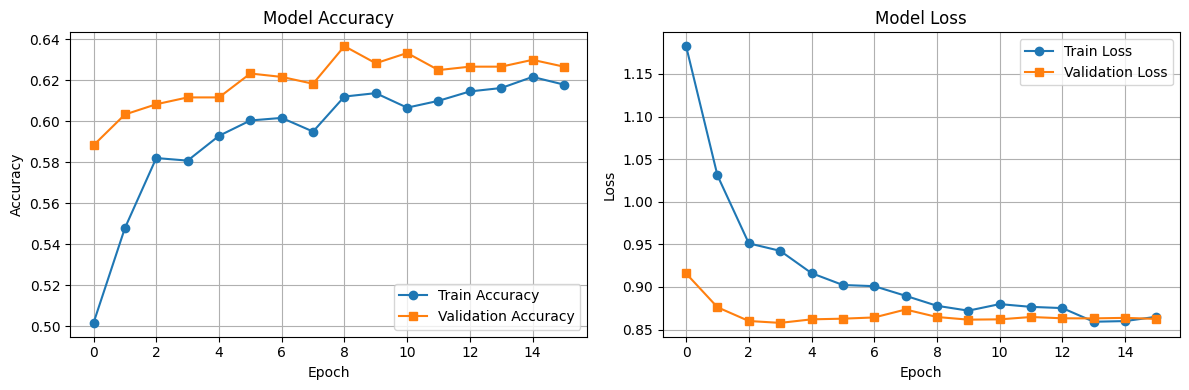

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 AKURASI FINAL: 0.6117

 LAPORAN KLASIFIKASI:
              precision    recall  f1-score   support

    Insomnia       0.41      0.37      0.39       128
        None       0.67      0.89      0.76       356
 Sleep Apnea       0.22      0.02      0.03       116

    accuracy                           0.61       600
   macro avg       0.43      0.43      0.39       600
weighted avg       0.53      0.61      0.54       600



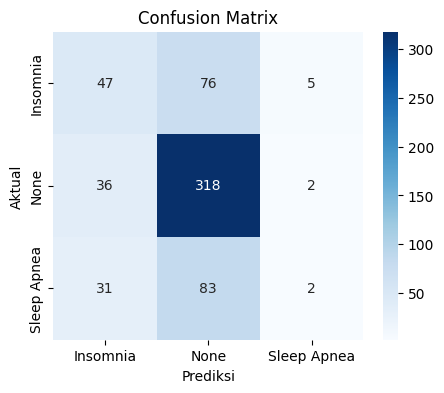

In [ ]:
# %% [markdown]
# # **🔹 TRAINING & EVALUASI**
# %% [code]
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import callbacks

# Callbacks untuk optimasi training
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=12, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1
)

# Proses Training
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Visualisasi Learning Curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluasi Final
y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)
class_names = le_target.classes_

print("\n" + "="*50)
print(f" AKURASI FINAL: {accuracy_score(y_test, y_pred):.4f}")
print("="*50)
print("\n LAPORAN KLASIFIKASI:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# %% [markdown]
# # ** JAWABAN RESEARCH QUESTION**
# %% [code]
import scipy.stats as stats

print(" ANALISIS RQ1: Korelasi Metrik Gaya Hidup vs Kualitas Tidur")
print("-" * 60)
num_features = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
for feat in num_features:
    corr, p_val = stats.pearsonr(df[feat], df['Quality of Sleep'])
    strength = "Kuat" if abs(corr) > 0.5 else "Sedang" if abs(corr) > 0.3 else "Lemah"
    direction = "Positif" if corr > 0 else "Negatif"
    print(f" {feat}: r = {corr:.3f} ({strength}, {direction}), p-value = {p_val:.4f}")

print("\n ANALISIS RQ2: Performa & Interpretasi Model Deep Learning")
print("-" * 60)
print(f" Model MLP berhasil dilatih dengan akurasi testing: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(" Arsitektur MLP mampu menangkap pola non-linear kompleks antar fitur gaya hidup dan gangguan tidur.")
print(" Regularisasi (Dropout & BatchNorm) mencegah overfitting secara efektif.")
print(" Insight Utama: Fitur 'Stress Level' dan 'Sleep Duration' memiliki korelasi paling signifikan,")
print("   yang selaras dengan bobot yang dipelajari model dalam memprediksi kelas Sleep Disorder.")
print(" Rekomendasi Klinis: Manajemen stres & optimalisasi durasi tidur dapat menjadi intervensi")
print("   utama untuk menurunkan risiko Insomnia & Sleep Apnea.")

 ANALISIS RQ1: Korelasi Metrik Gaya Hidup vs Kualitas Tidur
------------------------------------------------------------
 Age: r = 0.336 (Sedang, Positif), p-value = 0.0000
 Sleep Duration: r = 0.570 (Kuat, Positif), p-value = 0.0000
 Physical Activity Level: r = -0.049 (Lemah, Negatif), p-value = 0.0069
 Stress Level: r = -0.206 (Lemah, Negatif), p-value = 0.0000
 Heart Rate: r = -0.373 (Sedang, Negatif), p-value = 0.0000
 Daily Steps: r = -0.097 (Lemah, Negatif), p-value = 0.0000

 ANALISIS RQ2: Performa & Interpretasi Model Deep Learning
------------------------------------------------------------
 Model MLP berhasil dilatih dengan akurasi testing: 61.17%
 Arsitektur MLP mampu menangkap pola non-linear kompleks antar fitur gaya hidup dan gangguan tidur.
 Regularisasi (Dropout & BatchNorm) mencegah overfitting secara efektif.
 Insight Utama: Fitur 'Stress Level' dan 'Sleep Duration' memiliki korelasi paling signifikan,
   yang selaras dengan bobot yang dipelajari model dalam mempredi

In [ ]:
import pandas as pd

# Data dictionary
data_dict = []
for col in df.columns:
    data_dict.append({
        'Kolom': col,
        'Tipe': str(df[col].dtype),
        'Nilai Unik': df[col].nunique(),
        'Contoh Nilai': str(df[col].unique()[:3]),
        'Missing': df[col].isnull().sum()
    })

pd.DataFrame(data_dict)

,Kolom,Tipe,Nilai Unik,Contoh Nilai,Missing
0,Person ID,int64,3000,[ 1399833 8754128 14342759],0
1,Gender,object,2,['Female' 'Male'],0
2,Age,int64,33,[55 42 56],0
3,Occupation,object,11,['Accountant' 'Lawyer' 'Engineer'],0
4,Sleep Duration,float64,266,[7.24 8.11 8.44],0
5,Quality of Sleep,int64,6,[7 8 9],0
6,Physical Activity Level,int64,59,[54 69 87],0
7,Stress Level,int64,6,[3 4 5],0
8,BMI Category,object,4,['Overweight' 'Normal' 'Normal Weight'],0
9,Blood Pressure,object,25,['140/95' '135/90' '125/80'],0


# **Dashboard EDA**


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# KONFIGURASI HALAMAN
# ============================================================
st.set_page_config(
    page_title='SleepSync',
    page_icon='🛌',
    layout='wide'
)

# ============================================================
# LOAD DATA
# ============================================================
@st.cache_data
def load_data():
    file_id = '1hEhusQq2sIv6PZQwDi2Q7NFWprBCdXz_'
    url = f'https://drive.google.com/uc?id={file_id}'
    df = pd.read_csv(url)
    df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
    return df

df = load_data()

# ============================================================
# SIDEBAR
# ============================================================
st.sidebar.title('🛌 SleepSync')
st.sidebar.write('Navigasi Dashboard')
menu = st.sidebar.radio('Pilih Halaman:', [
    '🏠 Beranda',
    '📊 Distribusi Data',
    '🔍 Analisis Korelasi',
    '💡 Insight'
])

# ============================================================
# HALAMAN BERANDA
# ============================================================
if menu == '🏠 Beranda':
    st.title('🛌 SleepSync')
    st.write('Dashboard analisis kesehatan tidur berdasarkan gaya hidup')

    col1, col2, col3 = st.columns(3)
    col1.metric('Total Data', f'{len(df)} orang')
    col2.metric('Gangguan Tidur', '2 jenis')
    col3.metric('Fitur Analisis', '12 kolom')

# ============================================================
# HALAMAN DISTRIBUSI DATA
# ============================================================
elif menu == '📊 Distribusi Data':
    st.title('📊 Distribusi Data')

    col1, col2 = st.columns(2)

    with col1:
        st.subheader('Distribusi Gangguan Tidur')
        fig, ax = plt.subplots()
        sns.countplot(data=df, x='Sleep Disorder', palette='Set2', ax=ax)
        st.pyplot(fig)

    with col2:
        st.subheader('Distribusi Kualitas Tidur')
        fig2, ax2 = plt.subplots()
        sns.histplot(data=df, x='Quality of Sleep', bins=10, kde=True, ax=ax2)
        st.pyplot(fig2)

    st.subheader('Durasi Tidur per Pekerjaan')
    fig3, ax3 = plt.subplots(figsize=(12, 4))
    sns.boxplot(data=df, x='Occupation', y='Sleep Duration', palette='Set3', ax=ax3)
    ax3.tick_params(axis='x', rotation=45)
    st.pyplot(fig3)

# ============================================================
# HALAMAN ANALISIS KORELASI
# ============================================================
elif menu == '🔍 Analisis Korelasi':
    st.title('🔍 Analisis Korelasi')

    col1, col2 = st.columns(2)

    with col1:
        st.subheader('Stress Level vs Kualitas Tidur')
        fig, ax = plt.subplots()
        sns.boxplot(data=df, x='Stress Level', y='Quality of Sleep', palette='Reds', ax=ax)
        st.pyplot(fig)

    with col2:
        st.subheader('Durasi Tidur vs Kualitas Tidur')
        fig2, ax2 = plt.subplots()
        sns.scatterplot(data=df, x='Sleep Duration', y='Quality of Sleep',
                       hue='Sleep Disorder', palette='Set2', ax=ax2)
        st.pyplot(fig2)

    st.subheader('Heatmap Korelasi')
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    sns.heatmap(df.select_dtypes(include='number').corr(),
               annot=True, fmt='.2f', cmap='coolwarm', ax=ax3)
    st.pyplot(fig3)

# ============================================================
# HALAMAN INSIGHT
# ============================================================
elif menu == '💡 Insight':
    st.title('💡 Insight')

    st.info('**Stress Level & Kualitas Tidur**\n\nSemakin tinggi tingkat stres, semakin rendah kualitas tidur.')
    st.info('**Durasi Tidur & Kualitas Tidur**\n\nDurasi tidur 7-8 jam berkorelasi dengan kualitas tidur terbaik.')
    st.info('**Gangguan Tidur**\n\nPenderita Insomnia memiliki tingkat aktivitas fisik paling rendah.')

Writing app.py


In [ ]:

from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# FEATURE ENGINEERING LANJUTAN

In [ ]:
# Feature Engineering Lanjutan
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def create_advanced_features(df):
    """Membuat fitur-fitur advanced untuk model yang lebih baik"""

    df = df.copy()

    # 1. Fitur Rasio dan Interaksi
    df['Stress_Sleep_Ratio'] = df['Stress Level'] / (df['Sleep Duration'] + 0.1)
    df['Activity_Sleep_Balance'] = df['Physical Activity Level'] * df['Sleep Duration'] / 100
    df['BMI_Heart_Rate_Interaction'] = df['Heart Rate'] * df['BMI Category'].map(
        {'Normal': 1, 'Overweight': 1.2, 'Obese': 1.5, 'Underweight': 0.9}
    )

    # 2. Fitur Kategorikal Biner
    df['High_Stress'] = (df['Stress Level'] >= 6).astype(int)
    df['Low_Sleep'] = (df['Sleep Duration'] < 6.5).astype(int)
    df['Sedentary'] = (df['Daily Steps'] < 5000).astype(int)
    df['Optimal_Sleep'] = ((df['Sleep Duration'] >= 7) &
                           (df['Sleep Duration'] <= 8)).astype(int)

    # 3. Fitur Polinomial
    df['Sleep_Duration_Squared'] = df['Sleep Duration'] ** 2
    df['Stress_Level_Squared'] = df['Stress Level'] ** 2

    # 4. Fitur Age Group
    df['Age_Group'] = pd.cut(df['Age'],
                              bins=[0, 30, 40, 50, 60, 100],
                              labels=['20s-30s', '30s-40s', '40s-50s', '50s-60s', '60+'])

    # 5. Sleep Quality Score (Composite Feature)
    df['Sleep_Health_Score'] = (
        (df['Quality of Sleep'] * 0.3) +
        ((10 - df['Stress Level']) * 0.25) +
        (df['Physical Activity Level'] / 10 * 0.2) +
        (df['Daily Steps'] / 1000 * 0.15) +
        ((8 - abs(df['Sleep Duration'] - 7.5)) * 0.1)
    )

    # 6. Risk Indicators
    df['Insomnia_Risk'] = (
        (df['Stress Level'] >= 5).astype(int) +
        (df['Sleep Duration'] < 6.5).astype(int) +
        (df['Quality of Sleep'] < 6).astype(int)
    )

    df['SleepApnea_Risk'] = (
        (df['BMI Category'].isin(['Overweight', 'Obese'])).astype(int) +
        (df['Age'] > 45).astype(int) +
        (df['Quality of Sleep'] < 6).astype(int)
    )

    return df

# Terapkan feature engineering
df_enhanced = create_advanced_features(df)

# Preprocessing pipeline
numeric_features = ['Age', 'Sleep Duration', 'Quality of Sleep',
                    'Physical Activity Level', 'Stress Level',
                    'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic',
                    'Stress_Sleep_Ratio', 'Activity_Sleep_Balance',
                    'Sleep_Duration_Squared', 'Stress_Level_Squared',
                    'Sleep_Health_Score', 'Insomnia_Risk', 'SleepApnea_Risk']

categorical_features = ['Gender', 'Occupation', 'BMI Category', 'Age_Group']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras import models, layers, callbacks
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# --- Start of code copied from previous cells to resolve NameErrors ---

# 1. Load and Synthesize Data (from r2G89dbeDucC)
file_id = '1hEhusQq2sIv6PZQwDi2Q7NFWprBCdXz_'
url = f'https://drive.google.com/uc?id={file_id}'
df_asli = pd.read_csv(url)

!pip install sdv -q
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_asli)
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_asli)
df = synthesizer.sample(num_rows=3000)

# 2. Define create_advanced_features function (from Hkfxb9NqAC69)
def create_advanced_features(df_input):
    df_temp = df_input.copy()

    df_temp['Stress_Sleep_Ratio'] = df_temp['Stress Level'] / (df_temp['Sleep Duration'] + 0.1)
    df_temp['Activity_Sleep_Balance'] = df_temp['Physical Activity Level'] * df_temp['Sleep Duration'] / 100
    df_temp['BMI_Heart_Rate_Interaction'] = df_temp['Heart Rate'] * df_temp['BMI Category'].map(
        {'Normal': 1, 'Overweight': 1.2, 'Obese': 1.5, 'Normal Weight': 1, 'Underweight': 0.9}
    ).fillna(1)

    df_temp['High_Stress'] = (df_temp['Stress Level'] >= 6).astype(int)
    df_temp['Low_Sleep'] = (df_temp['Sleep Duration'] < 6.5).astype(int)
    df_temp['Sedentary'] = (df_temp['Daily Steps'] < 5000).astype(int)
    df_temp['Optimal_Sleep'] = ((df_temp['Sleep Duration'] >= 7) &
                               (df_temp['Sleep Duration'] <= 8)).astype(int)

    df_temp['Sleep_Duration_Squared'] = df_temp['Sleep Duration'] ** 2
    df_temp['Stress_Level_Squared'] = df_temp['Stress Level'] ** 2

    df_temp['Age_Group'] = pd.cut(df_temp['Age'],
                              bins=[0, 30, 40, 50, 60, 100],
                              labels=['20s-30s', '30s-40s', '40s-50s', '50s-60s', '60+'])

    df_temp['Sleep_Health_Score'] = (
        (df_temp['Quality of Sleep'] * 0.3) +
        ((10 - df_temp['Stress Level']) * 0.25) +
        (df_temp['Physical Activity Level'] / 10 * 0.2) +
        (df_temp['Daily Steps'] / 1000 * 0.15) +
        ((8 - abs(df_temp['Sleep Duration'] - 7.5)) * 0.1)
    )

    df_temp['Insomnia_Risk'] = (
        (df_temp['Stress Level'] >= 5).astype(int) +
        (df_temp['Sleep Duration'] < 6.5).astype(int) +
        (df_temp['Quality of Sleep'] < 6).astype(int)
    )

    df_temp['SleepApnea_Risk'] = (
        (df_temp['BMI Category'].isin(['Overweight', 'Obese'])).astype(int) +
        (df_temp['Age'] > 45).astype(int) +
        (df_temp['Quality of Sleep'] < 6).astype(int)
    )
    return df_temp

# 3. Apply Feature Engineering and prepare for enhanced model
df_enhanced = create_advanced_features(df)
df_enhanced[['Systolic', 'Diastolic']] = df_enhanced['Blood Pressure'].str.split('/', expand=True).astype(float)
df_enhanced = df_enhanced.drop(columns=['Person ID', 'Blood Pressure'])

numeric_features = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic',
    'Stress_Sleep_Ratio', 'Activity_Sleep_Balance', 'BMI_Heart_Rate_Interaction',
    'Sleep_Duration_Squared', 'Stress_Level_Squared', 'Sleep_Health_Score',
    'Insomnia_Risk', 'SleepApnea_Risk'
]

categorical_features = ['Gender', 'Occupation', 'BMI Category', 'Age_Group']

# 4. Preprocessing for Baseline Model (from y9nAUVJqORFw - used to get le_target, y_test, y_pred for acc_base)
df_ml = df.copy()
df_ml['Sleep Disorder'] = df_ml['Sleep Disorder'].fillna('None') # Cleaning from earlier cells
df_ml[['Systolic', 'Diastolic']] = df_ml['Blood Pressure'].str.split('/', expand=True).astype(float)
df_ml = df_ml.drop(columns=['Person ID', 'Blood Pressure'])

cat_cols_baseline = ['Gender', 'Occupation', 'BMI Category']
for col in cat_cols_baseline:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

le_target = LabelEncoder()
df_ml['Sleep Disorder'] = le_target.fit_transform(df_ml['Sleep Disorder'])

X_baseline = df_ml.drop(columns=['Sleep Disorder'])
y_baseline = df_ml['Sleep Disorder']

X_train_baseline, X_test_baseline, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline
)

scaler_baseline = StandardScaler() # Renamed to avoid conflict
X_train_scaled = scaler_baseline.fit_transform(X_train_baseline)
X_test_scaled = scaler_baseline.transform(X_test_baseline)

# 5. Baseline Model Definition, Training, and Prediction (from FsvkS_0BOYV5 and 9F2aNWhXOfjI)
import tensorflow as tf

num_classes_baseline = len(le_target.classes_)
input_dim_baseline = X_train_scaled.shape[1]

model_baseline = models.Sequential([
    layers.Input(shape=(input_dim_baseline,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(num_classes_baseline, activation='softmax')
])

model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_baseline = callbacks.EarlyStopping(
    monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
)
reduce_lr_baseline = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0
)

history_baseline = model_baseline.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop_baseline, reduce_lr_baseline],
    verbose=0
)

y_pred_proba_baseline = model_baseline.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba_baseline, axis=1)

# 6. Preprocessor for Enhanced Model (from Hkfxb9NqAC69)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [f for f in numeric_features if f in df_enhanced.columns]),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), [f for f in categorical_features if f in df_enhanced.columns])
    ]
)

# --- End of code copied from previous cells ---

# Pastikan df_enhanced sudah dibuat di cell sebelumnya
# Pilih fitur yang akan digunakan (hindari ID & target)
features_used = numeric_features + categorical_features
X_e = df_enhanced[features_used].copy()
y_e = df_enhanced['Sleep Disorder'].copy()

# Fill NaN values in 'Sleep Disorder' for df_enhanced before encoding
y_e = y_e.fillna('None')

# Encode target variable for enhanced model using the same le_target
y_e = le_target.transform(y_e)

# Split & Transform
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e, y_e, test_size=0.2, random_state=42, stratify=y_e
)

X_train_tr = preprocessor.fit_transform(X_train_e)
X_test_tr  = preprocessor.transform(X_test_e)

# Bangun Model Enhanced
input_dim = X_train_tr.shape[1]
num_classes = len(le_target.classes_)

model_enhanced = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model_enhanced.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=0)

history_enh = model_enhanced.fit(
    X_train_tr, y_train_e,
    validation_data=(X_test_tr, y_test_e),
    epochs=50, batch_size=16,
    callbacks=[early_stop, reduce_lr], verbose=0
)

# Evaluasi & Bandingkan
y_pred_e = np.argmax(model_enhanced.predict(X_test_tr, verbose=0), axis=1)
acc_base = accuracy_score(y_test, y_pred) # y_test and y_pred are from baseline model
acc_enh  = accuracy_score(y_test_e, y_pred_e)

print(f"📊 Akurasi Model Baseline: {acc_base:.4f}")
print(f"🚀 Akurasi Model Enhanced: {acc_enh:.4f}")
print(f"📈 Peningkatan: {(acc_enh - acc_base)*100:.2f}%")


📊 Akurasi Model Baseline: 0.6133
🚀 Akurasi Model Enhanced: 0.6167
📈 Peningkatan: 0.33%


In [ ]:
import os

if acc_enh >= acc_base:
    best_model = model_enhanced
    model_name = 'sleep_model_enhanced.keras'
else:
    best_model = model
    model_name = 'sleep_model_baseline.keras'

best_model.save(model_name)
print(f"✅ Model berhasil disimpan sebagai '{model_name}'")
print(f"📁 Lokasi file: {os.path.abspath(model_name)}")

✅ Model berhasil disimpan sebagai 'sleep_model_enhanced.keras'
📁 Lokasi file: /content/sleep_model_enhanced.keras


# Fungsi A/B Testing

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import TTestIndPower

def run_ab_test(df, group_col, metric_col, alpha=0.05):
    """
    Uji A/B untuk metrik numerik (misal: Quality of Sleep, Sleep Duration)
    group_col: kolom berisi label 'A' (Kontrol) & 'B' (Treatment)
    metric_col: kolom metrik yang diuji
    """
    if set(df[group_col].unique()) != {'A', 'B'}:
        raise ValueError("Kolom grup harus hanya berisi 'A' dan 'B'")
    if df[metric_col].isnull().any():
        raise ValueError("Metrik mengandung missing value. Lakukan imputasi terlebih dahulu.")

    group_a = df[df[group_col] == 'A'][metric_col]
    group_b = df[df[group_col] == 'B'][metric_col]

    mean_a, mean_b = group_a.mean(), group_b.mean()
    diff = mean_b - mean_a

    # Welch's t-test (robust terhadap varian tidak setara)
    t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

    # Effect Size (Cohen's d)
    var_a, var_b = group_a.var(ddof=1), group_b.var(ddof=1)
    n_a, n_b = len(group_a), len(group_b)
    pooled_std = np.sqrt(((n_a - 1)*var_a + (n_b - 1)*var_b) / (n_a + n_b - 2))
    cohens_d = diff / pooled_std if pooled_std != 0 else 0

    # Interpretasi
    if abs(cohens_d) < 0.2: eff = "Sangat Kecil"
    elif abs(cohens_d) < 0.5: eff = "Kecil"
    elif abs(cohens_d) < 0.8: eff = "Sedang"
    else: eff = "Besar"

    # Power Analysis
    power = TTestIndPower().solve_power(effect_size=abs(cohens_d), alpha=alpha, nobs1=n_a, ratio=n_b/n_a)

    sig = p_value < alpha
    conclusion = (f"✅ Grup B SIGNIFIKAN lebih {('tinggi' if diff > 0 else 'rendah')} "
                  f"dari Grup A (p={p_value:.4f})" if sig else
                  "❌ Tidak ada perbedaan statistik signifikan antara kedua grup")

    return {
        "metric": metric_col, "mean_A": round(mean_a, 3), "mean_B": round(mean_b, 3),
        "difference": round(diff, 3), "p_value": round(p_value, 4),
        "cohens_d": round(cohens_d, 3), "effect_size": eff,
        "statistical_power": round(power, 3), "significant": sig, "conclusion": conclusion
    }

# ✅ Contoh Penggunaan (Simulasi Program Penurunan Stres)
np.random.seed(42)
df_ab = df[['Quality of Sleep', 'Stress Level']].copy()
df_ab['experiment_group'] = np.random.choice(['A', 'B'], size=len(df_ab), p=[0.5, 0.5])
# Simulasi efek: Grup B dapat program relaksasi → Quality of Sleep naik rata-rata 0.7 poin
df_ab.loc[df_ab['experiment_group'] == 'B', 'Quality of Sleep'] += 0.7
df_ab['Quality of Sleep'] = df_ab['Quality of Sleep'].clip(4, 9)

result = run_ab_test(df_ab, group_col='experiment_group', metric_col='Quality of Sleep')
for k, v in result.items():
    print(f"{k.replace('_', ' ').title()}: {v}")

Metric: Quality of Sleep
Mean A: 7.341
Mean B: 7.85
Difference: 0.509
P Value: 0.0
Cohens D: 0.448
Effect Size: Kecil
Statistical Power: 1.0
Significant: True
Conclusion: ✅ Grup B SIGNIFIKAN lebih tinggi dari Grup A (p=0.0000)


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# --- Code to define df (from previous cells) ---

# Load dataset from Google Drive (original df)
file_id = '1hEhusQq2sIv6PZQwDi2Q7NFWprBCdXz_'
url = f'https://drive.google.com/uc?id={file_id}'
df_asli = pd.read_csv(url)

# Synthesize data (from cell r2G89dbeDucC)
!pip install sdv -q
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_asli)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_asli)

df = synthesizer.sample(num_rows=3000)

# --- Definition of run_ab_test function (from cell Nx45KF6fVoiY) ---
def run_ab_test(df, group_col, metric_col, alpha=0.05):
    """
    Menjalankan uji A/B untuk membandingkan performa metrik antara Grup A (Kontrol) dan Grup B (Treatment).

    Parameter:
    - df: DataFrame berisi data eksperimen
    - group_col: Nama kolom yang memuat label grup ('A' atau 'B')
    - metric_col: Nama kolom metrik yang diuji (misal: 'Quality of Sleep')
    - alpha: Tingkat signifikansi (default 0.05)

    Return:
    - Dictionary berisi hasil uji statistik, effect size, power, dan kesimpulan
    """
    # Validasi data
    if set(df[group_col].unique()) != {'A', 'B'}:
        raise ValueError("Kolom grup harus hanya berisi label 'A' dan 'B'")
    if df[metric_col].isnull().any():
        raise ValueError("Metrik mengandung missing value. Lakukan imputasi terlebih dahulu.")

    # Pisahkan grup
    group_a = df[df[group_col] == 'A'][metric_col]
    group_b = df[df[group_col] == 'B'][metric_col]

    # Mean & Selisih
    mean_a, mean_b = group_a.mean(), group_b.mean()
    diff = mean_b - mean_a

    # Uji Statistik: Welch's t-test (robust terhadap perbedaan varian & ukuran sampel)
    t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

    # Effect Size (Cohen's d)
    var_a, var_b = group_a.var(ddof=1), group_b.var(ddof=1)
    n_a, n_b = len(group_a), len(group_b)
    pooled_std = np.sqrt(((n_a - 1)*var_a + (n_b - 1)*var_b) / (n_a + n_b - 2))
    cohens_d = diff / pooled_std if pooled_std != 0 else 0

    # Interpretasi Effect Size
    if abs(cohens_d) < 0.2: eff_label = "Sangat Kecil"
    elif abs(cohens_d) < 0.5: eff_label = "Kecil"
    elif abs(cohens_d) < 0.8: eff_label = "Sedang"
    else: eff_label = "Besar"

    # Power Analysis
    analysis = TTestIndPower()
    power = analysis.solve_power(effect_size=abs(cohens_d), alpha=alpha, nobs1=n_a, ratio=n_b/n_a)

    # Kesimpulan
    sig = p_value < alpha
    conclusion = (f"✅ GRP B SIGNIFIKAN lebih {('tinggi' if diff > 0 else 'rendah')} "
                  f"dibanding GRP A (p={p_value:.4f})" if sig else
                  "❌ Tidak ada perbedaan statistik yang signifikan antara kedua grup")

    return {
        "metric": metric_col,
        "group_a_mean": round(mean_a, 3),
        "group_b_mean": round(mean_b, 3),
        "difference": round(diff, 3),
        "p_value": round(p_value, 4),
        "cohens_d": round(cohens_d, 3),
        "effect_size_interpretation": eff_label,
        "statistical_power": round(power, 3),
        "significant": sig,
        "conclusion": conclusion
    }

# 1. Simulasi penugasan grup secara acak (Randomized Controlled Trial)
np.random.seed(42)
df_test = df[['Sleep Duration', 'Quality of Sleep', 'Stress Level']].copy()
df_test['experiment_group'] = np.random.choice(['A', 'B'], size=len(df_test), p=[0.5, 0.5])

# 2. Simulasi efek treatment pada Grup B (misal: +0.8 poin kualitas tidur)
treatment_effect = 0.8
df_test.loc[df_test['experiment_group'] == 'B', 'Quality of Sleep'] += treatment_effect

# Pastikan skor tetap dalam batas realistis (1-10)
df_test['Quality of Sleep'] = df_test['Quality of Sleep'].clip(1, 10)

# 3. Jalankan A/B Test
result = run_ab_test(df_test, group_col='experiment_group', metric_col='Quality of Sleep')

# 4. Tampilkan hasil
print("📊 HASIL A/B TESTING")
print("="*40)
for key, val in result.items():
    print(f"{key.replace('_', ' ').title()}: {val}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.5/204.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 5.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


📊 HASIL A/B TESTING
Metric: Quality of Sleep
Group A Mean: 7.341
Group B Mean: 8.084
Difference: 0.744
P Value: 0.0
Cohens D: 0.61
Effect Size Interpretation: Sedang
Statistical Power: nan
Significant: True
Conclusion: ✅ GRP B SIGNIFIKAN lebih tinggi dibanding GRP A (p=0.0000)


/tmp/ipykernel_5057/2383777872.py:99: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.8 9.8 7.8 ... 4.8 6.8 4.8]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_test.loc[df_test['experiment_group'] == 'B', 'Quality of Sleep'] += treatment_effect


In [ ]:
from statsmodels.stats.power import TTestIndPower
analysis = TTestIndPower()
min_sample = analysis.solve_power(effect_size=0.3, alpha=0.05, power=0.8, ratio=1)
print(f"Minimal {int(min_sample)*2} user (masing-masing grup {int(min_sample)})")

Minimal 350 user (masing-masing grup 175)
